## 02 Feature Engineering
### 01 - Filter Methoden

### 01.1 Korrelaion

In [ ]:
numeric_features = df_train_order.select_dtypes(include= ['int','float']).columns
print(numeric_features)

Index(['lineID', 'day', 'pid', 'adFlag', 'availability', 'competitorPrice',
       'click', 'basket', 'order', 'price', 'revenue', 'manufacturer',
       'genericProduct', 'salesIndex', 'category', 'rrp', 'has_campaign',
       'is_multipack', 'pack_n', 'pack_size', 'salesIndex_norm',
       'competitorPrice_clean', 'price_clean', 'rrp_clean',
       'competitorPrice_missing', 'day_7', 'day_14', 'day_30', 'price_diff',
       'price_discount', 'price_discount_diff', 'competitorPrice_discount',
       'is_lower_price', 'is_discount', 'is_greater_discount', 'rrp_per_unit',
       'price_per_unit', 'competitorPrice_per_unit', 'pid_total_events',
       'click_time', 'basket_time', 'order_time', 'group12_order',
       'week_order'],
      dtype='object')


### Korrelationsmatrix

<function matplotlib.pyplot.show(close=None, block=None)>

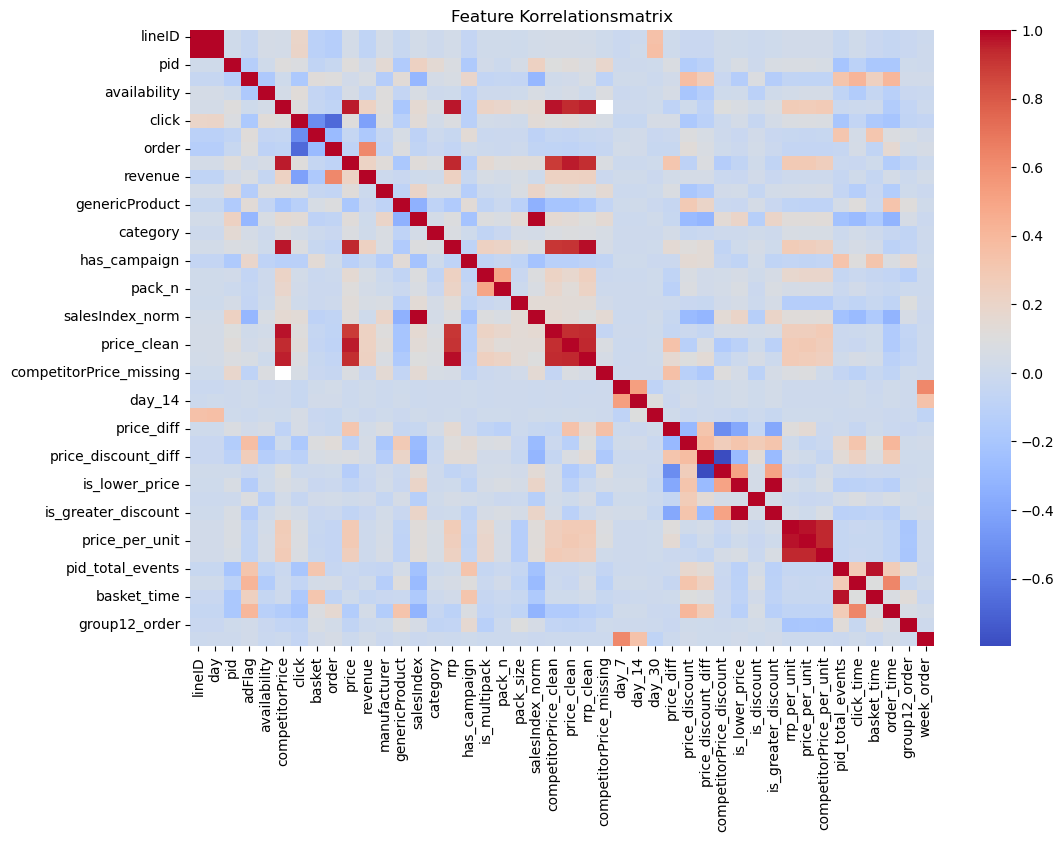

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_train_order[numeric_features].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap = "coolwarm")
plt.title("Feature Korrelationsmatrix")
plt.show

### Korrelation in Zahlen
#### Alle Korrelationen

In [ ]:
corr_all = df_train_order[numeric_features].corr()
print(corr_all)

                            lineID       day       pid    adFlag  \
lineID                    1.000000  0.994014  0.011988 -0.043667   
day                       0.994014  1.000000  0.012678 -0.044258   
pid                       0.011988  0.012678  1.000000 -0.132461   
adFlag                   -0.043667 -0.044258 -0.132461  1.000000   
availability              0.039332  0.040637  0.010405 -0.174478   
competitorPrice           0.034118  0.035945  0.103401  0.006598   
click                     0.198165  0.205010  0.086740 -0.181142   
basket                   -0.105333 -0.108702 -0.072548  0.116084   
order                    -0.131996 -0.136788 -0.034962  0.103573   
price                     0.032295  0.034331  0.112775  0.020339   
revenue                  -0.078075 -0.080655  0.021697  0.070995   
manufacturer              0.034413  0.035292  0.148351 -0.139469   
genericProduct           -0.035595 -0.037418 -0.160734  0.131910   
salesIndex                0.028460  0.028927  0.

In [ ]:
import seaborn as sns

sns.pairplot(corr_all)

#### Nur starke Korrelationen > 0.8

In [ ]:
import numpy as np
corr = df_train_order[numeric_features].corr()

# Korrelation gleicher Features aussortieren
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Nur starke Korrelationen > 0.8
strong_corr = corr_pairs.stack().reset_index()
strong_corr.columns = ['Feature 1', 'Feature 2', 'Correlation']

strong_corr = strong_corr[abs(strong_corr['Correlation']) > 0.8]

print(strong_corr.sort_values(by="Correlation", ascending=False))

                 Feature 1                 Feature 2  Correlation
486             salesIndex           salesIndex_norm     1.000000
880         is_lower_price       is_greater_discount     1.000000
0                   lineID                       day     0.994014
546                    rrp                 rrp_clean     0.981130
931       pid_total_events               basket_time     0.977237
220        competitorPrice     competitorPrice_clean     0.976058
909           rrp_per_unit            price_per_unit     0.973697
214        competitorPrice                       rrp     0.967174
362                  price               price_clean     0.961301
208        competitorPrice                     price     0.959289
222        competitorPrice                 rrp_clean     0.953897
917         price_per_unit  competitorPrice_per_unit     0.941741
910           rrp_per_unit  competitorPrice_per_unit     0.941478
355                  price                       rrp     0.941444
714       

#### Korrelation mit Targetvariabel "order"

In [ ]:
corr_target = df_train_order[numeric_features].corr()["order"]
corr_target = corr_target.reset_index()
corr_target.columns = ["Feature", "Correlation with Order"]
corr_target = corr_target.sort_values(
    "Correlation with Order",
    ascending=False
)
print(corr_target)

                     Feature  Correlation with Order
8                      order                1.000000
10                   revenue                0.624374
41                order_time                0.162978
29            price_discount                0.126156
3                     adFlag                0.103573
12            genericProduct                0.091205
30       price_discount_diff                0.069950
43                week_order                0.048575
39                click_time                0.043348
33               is_discount                0.029897
42             group12_order                0.029429
25                     day_7                0.029009
26                    day_14                0.023398
16              has_campaign                0.010745
31  competitorPrice_discount                0.009270
19                 pack_size               -0.000832
17              is_multipack               -0.008087
18                    pack_n               -0.

### 01.2 Mutual Information
Misst wie viel Information ein Feature über das Target enthält. Sklearn nutzt den k-nearest neighbor Ansatz.
Für jeden Datenpunkt werden die k nächsten Nachbarn im Feature Raum gesucht. Daraus wird geschätzt, wie dicht die Punkte liegen wie stark X und Y zusammen auftrettten.
Misst wie stark sich die Wahrscheinlichkeit von Y ändert, wenn X bekannt ist.
Gut weil:
- Rabattwirkungen haben oft Schwellen (ab einem Zeitpunkt sinken die orders, trotz steigendem Rabatt)
- Preiswirkungen sind oft nicht linear
- Verfügbarkeit wirkt sprunghaft

-> Sehr rechenintensiv, besser mit sample machen

In [ ]:
from sklearn.feature_selection import mutual_info_classif

# Features und Target definieren
X = df_train.drop(columns=["order"])
y = df_train["order"]

# Missing Flag für competitorPrice erstellen, damit klar ist wie mit NaN umgegangen wird (0 = Preis vorhanden, 1 = Preis missing)
X["competitorPrice_missing"] = X["competitorPrice"].isna().astype(int)

# nummerische Features
X_numeric = X.select_dtypes(include=["int","float"])

# NaN müssen trotzdem ersetzt werden
X_numeric = X_numeric.fillna(X_numeric.median())

# Mutual Information berechnen
mi_scores = mutual_info_classif(X_numeric, y, random_state=42)

# Ergebnisse in Tabelle
mi_scores = pd.Series(mi_scores, index=X_numeric.columns)

mi_scores = mi_scores.sort_values(ascending=False)

print(mi_scores)


KeyboardInterrupt: 

#### Interpretation Werte
MI >= 0 -> Je höher der Wert, deso mehr Informationen über das Target enthält das Feature
| Wertbereich | Zusammenhang |
|-------------|--------------|
| 0           | kein Zusammenhang |
| 0.001 - 0.01 | sehr schwach |
| 0.01 - 0.05 | schwach |
| 0.05 - 0.15 | mittel |
| > 0.15      | stark |


Achtung revenue und click "kommen" quais aus orders, deshalb müssen sie entfernt werden.
LineID ist kein richitges Feature, weshalb auch dieses entfernt werden muss.

In [ ]:
# Visualisierung
import matplotlib.pyplot as plt

mi_scores.plot.bar(figsize=(10,5))
plt.title("Mutual Information Scores")
plt.show()